<a href="https://colab.research.google.com/github/100car/PythonProject/blob/main/diploma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дипломна робота
## КОМП'ЮТЕРНА АКАДЕМІЯ IT STEP

![КОМП'ЮТЕРНА АКАДЕМІЯ IT STEP](https://raw.githubusercontent.com/100car/examination/main/logo_it_step.jpg)

**Курс:** Штучний інтелект з використанням Python

**Тема:** Інтелектуальна система аналізу та прогнозування продажів на основі неструктурованих Excel-звітів

**Група:** AI+Python52

**Викладач:** Галиш Антон

**Виконав:** Токар Сергій
## Мета роботи:
Розробка пайплайну для обробки "сирих" Excel-файлів, проведення розвідувального аналізу (EDA), сегментація товарів/клієнтів (Clustering) та побудова моделі прогнозування продажів (ML).

# Підготовка середовища Colab

Ідемо шляхом «тонкого» ноутбука: в ipynb-файлі тільки підготовка, конфігурація, запуск пайплайна і демонстрація результатів. Вся основна логіка в py-файлах репозиторію GitHub (так зручніше тестувати й підтримувати), усі складні і не дуже перетворення винесені в окремі модулі.

### Клонуємо репозиторій з кодом та даними

In [11]:
import os, sys, pathlib

REPO_URL = "https://github.com/100car/examination.git"
REPO_DIR = "examination"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
%cd {REPO_DIR}

# (Опційно) завжди тягнемо останні зміни
!git pull --ff-only


Cloning into 'examination'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 198 (delta 88), reused 129 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (198/198), 1.60 MiB | 23.68 MiB/s, done.
Resolving deltas: 100% (88/88), done.
/content/examination/examination
Already up to date.


### Структура даних пайплайну:
```
DATA/
├─ SKU/
│  └─ sku_master.xlsx                 # Головний файл з інформацією по SKU
└─ SALES/
   ├─ SALES_REPORTS/                  # Вхідні звіти продажів по регіонах
   ├─ RECOGNIZED_SALES_REPORTS/       # Розпізнані звіти (евристики + LLM)
   ├─ MONTHLY_SALES_CORRECTED/        # Скориговані користувачем медіани
   ├─ REGIONAL_ARRIVALS/              # Вхідні надходження по регіонах
   ├─ TRANSIT_PLANNED_ARRIVALS/       # Планові надходження на транзитні склади
   ├─ TRANSIT_PLANNED_SHIPMENTS/      # Планові відвантаження з транзитних складів
   ├─ TRANSIT_STOCK_STATUS/           # Статуси залишків на транзитних складах
   ├─ RESULT/                         # Вихідні результати пайплайна
   │  └─ results.xlsx                 # зберігатимуться у цьому файлі
   └─ LOGS/                           # Детальні логи виконання
```

Пайплайн передбачає, що всі модулі працюють із цією структурою. Зараз відбулося завантаження необхідних файлів даних у вигляді таблиць Excel, "шматки" пайтонівського коду, файл "вимог" та конфігурації.


### Встановлюємо вимоги (requirements.txt)



In [12]:
!pip -q install -r DATA/requirements.txt

### Налаштовуємо секретний ключ (для LLM-моделі)

In [13]:
# GEMINI_API_KEY збережено через Colab > Secrets
import os
try:
    from google.colab import userdata
    key = userdata.get("GEMINI_API_KEY")
    if key:
        os.environ["GEMINI_API_KEY"] = key
except Exception:
    pass

# Перевіримо, що ключ є (не друкуємо його!)
HAS_GEMINI_KEY = bool(os.environ.get("GEMINI_API_KEY"))
print("GEMINI_API_KEY set:", HAS_GEMINI_KEY)


GEMINI_API_KEY set: True


### Конфігурація пайплайна

Щоб не хардкодити шляхи / параметри в коді, використовуємо окремий конфіг-файл.
Нижче — завантаження `config.yaml` (або дефолтний конфіг, якщо файла ще нема).

#### Примітка:

Файл config.yaml підготовлений для подальшого винесення параметрів пайплайну,
але в межах поточної реалізації всі ключові шляхи і параметри поки що зафіксовані в коді.

In [14]:
# Конфіг: читаємо config.yaml + дефолти (deep-merge) + готуємо змінні/директорії
from pathlib import Path
import yaml
import os

CFG_PATH = Path("config.yaml")

default_cfg = {
    "paths": {
        "data_root": "DATA",
        "sku_master": "DATA/SKU/sku_master.xlsx",
        "sales_reports_dir": "DATA/SALES/SALES_REPORTS",
        "result_dir": "DATA/SALES/RESULT",
        "result_workbook": "DATA/SALES/RESULT/results.xlsx",
    },
    "pipeline": {
        "debug": True,
        "llm_enabled": True,
    }
}

def deep_merge(base: dict, override: dict) -> dict:
    """Рекурсивно зливає словники: override має пріоритет."""
    out = dict(base)
    for k, v in (override or {}).items():
        if isinstance(v, dict) and isinstance(out.get(k), dict):
            out[k] = deep_merge(out[k], v)
        else:
            out[k] = v
    return out

user_cfg = {}
if CFG_PATH.exists():
    user_cfg = yaml.safe_load(CFG_PATH.read_text(encoding="utf-8")) or {}

cfg = deep_merge(default_cfg, user_cfg)

# 1) Авто-вимкнення LLM, якщо ключа нема
# HAS_GEMINI_KEY береться з попередньої комірки з секретом; якщо її не було — підстрахуємось:
HAS_GEMINI_KEY = globals().get("HAS_GEMINI_KEY", bool(os.environ.get("GEMINI_API_KEY")))

if cfg["pipeline"].get("llm_enabled", False) and not HAS_GEMINI_KEY:
    cfg["pipeline"]["llm_enabled"] = False
    print("⚠️ GEMINI_API_KEY не задано — LLM вимкнено (pipeline.llm_enabled=False).")

# 2) Зручні змінні для наступних кроків ноутбука
DATA_ROOT = Path(cfg["paths"]["data_root"])
RESULT_DIR = Path(cfg["paths"]["result_dir"])
RESULT_XLSX = Path(cfg["paths"]["result_workbook"])

# 3) Гарантуємо, що папка під results.xlsx існує
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# 4) Прокидуємо базові налаштування в env (щоб модулі могли читати, якщо захочеш)
os.environ["PIPELINE_DEBUG"] = "1" if cfg["pipeline"].get("debug") else "0"
os.environ["PIPELINE_LLM_ENABLED"] = "1" if cfg["pipeline"].get("llm_enabled") else "0"
os.environ["PIPELINE_RESULT_XLSX"] = str(RESULT_XLSX)

print("Config loaded ✅")
print("RESULT_XLSX =", RESULT_XLSX)
print("LLM enabled =", cfg["pipeline"]["llm_enabled"])

cfg


Config loaded ✅
RESULT_XLSX = DATA/SALES/RESULT/results.xlsx
LLM enabled = True


{'paths': {'data_root': 'DATA',
  'sku_master': 'DATA/SKU/sku_master.xlsx',
  'sales_reports_dir': 'DATA/SALES/SALES_REPORTS',
  'result_dir': 'DATA/SALES/RESULT',
  'result_workbook': 'DATA/SALES/RESULT/results.xlsx'},
 'pipeline': {'debug': True, 'llm_enabled': True}}

## STEP 01. Пакетний парсер Excel-звітів продажів по регіонам

Зчитуємо з папки
```
DATA/
└─ SALES/
   └─ SALES_REPORTS/                  
```
всі звіти продажів по регіонах (три: Україна, Узбекистан та Казахстан, - або менше). Якщо за допомогою евристичного аналізу не вдається розпізнати заголовки стовбчиків, то використовуємо LLM (Gemini API).
Важливі правила для обробки:
- Рядки без Symbol (артикула) НЕ переносимо у вихідний файл.
- Якщо у заголовках є "ОС" (після нормалізації -> "ос") — це Stock і регіон UZ визначається однозначно.
- Перед аналізом "розкриваємо" всі приховані колонки (hidden=False) і вже потім детектимо/рахуємо.
- TOTAL у вихідному файлі завжди перераховується як сума місяців.
Якщо у вхідному файлі був власний Total — підсвічуємо mismatch червоним.

In [15]:
!python DATA/build_results_workbook.py

STEP 1 | Build results workbook | 2026-01-27 09:54:36
OK   25_12_30_Продажа_АМР_за_январь_декабрь_2025_г_.xls.xlsx  | det=H   | region=KZ  | checked=349  | mismatches=0    | saved=KZ_25_12_30_Продажа_АМР_за_январь_декабрь_2025_г_.xls_sales_recognized.xlsx
OK   amp monthly december.xlsx                                | det=LLM | region=UZ  | checked=598  | mismatches=0    | saved=UZ_amp monthly december_sales_recognized.xlsx
OK   UA2025.xlsx                                              | det=H   | region=UA  | checked=1017 | mismatches=0    | saved=UA_UA2025_sales_recognized.xlsx
OK   | step=1 | saved=/content/examination/examination/DATA/SALES/RESULT/results.xlsx
Проаналізовано: 3 файлів | Сформовано: 3 файлів (із них за допомогою LLM: 1)
OK   | step=1 | saved=/content/examination/examination/DATA/SALES/RESULT/results.xlsx


## Результати першого етапу
У ході виконання модуля build_results_workbook сформовано зведений Excel-файл, що містить окремі аркуші зі звітами продаж по регіонам:
*   UA-sales (Україна))
*   UZ-sales (Узбекистан)
*   KZ-sales (Казахстан)

Кожен аркуш включає агреговані показники продажів відповідного регіону та використовується на наступних етапах обробки даних.

## STEP 02. Формування регіональних надходжень товарів

На цьому етапі виконується побудова допоміжних аркушів із регіональними надходженнями товарів
(UA+, KZ+, UZ+), які використовуються для подальшої нормалізації та розрахунку скоригованих
місячних продажів.

Скрипт `regional_arrivals.py` виконує такі дії:
- зчитує зведену таблицю результатів продажів;
- нормалізує товарні коди (SKU) з використанням довідника `sku_master.xlsx`;
- агрегує надходження за регіонами;
- додає до Excel-файлу нові аркуші з регіональними надходженнями.

Результатом виконання є розширений файл результатів, що містить регіональні дані,
необхідні для подальших етапів аналітики.

In [16]:
!python DATA/regional_arrivals.py

STEP 2 | Build regional arrivals sheets | 2026-01-27 09:54:46
OK   | region=UA | in=48    | unique=48    | merged=0     | green=0    | red=2    | saved=UA+ | file=05.01.2025 UA.xlsx
OK   | region=KZ | in=269   | unique=192   | merged=77    | green=4    | red=0    | saved=KZ+ | file=KZ-12+order.xlsx
OK   | region=UZ | in=103   | unique=101   | merged=2     | green=0    | red=0    | saved=UZ+ | file=UZ_amp 2025.xlsx
OK   | step=2 | saved=/content/examination/examination/DATA/SALES/RESULT/results.xlsx


## STEP 03. Нормалізація результатів та уніфікація місячних показників

На цьому етапі виконується фінальна нормалізація зведеного файлу результатів продажів.
Скрипт `normalize_results_workbook.py` приводить дані до єдиного формату,
придатного для подальшого аналізу та використання в моделях машинного навчання.

Основні дії скрипта:
- уніфікація назв місяців до стандартного формату  
  (`янв`, `фев`, `мар`, `апр`, `май`, `июн`, `июл`, `авг`, `сен`, `окт`, `ноя`, `дек`);
- нормалізація товарних ідентифікаторів (`Symbol_normalized`);
- застосування місячних корекцій продажів (за наявності файлів корекцій);
- розрахунок скоригованих показників продажів;
- формування фінальних аркушів `*-normalized`.

Отримані таблиці представляють собою стандартизовані часові ряди,
готові для статистичного аналізу, кластеризації та прогнозування попиту.


In [17]:
!python DATA/normalize_results_workbook.py --include-arrivals-added-col

STEP 3 | Normalize results workbook | 2026-01-27 09:54:49
OK   | region=UA | in=1017  | unique=1017  | merged=0     | green=0    | red=25   | arrivals_added=46   | saved=UA-normalized
OK   | region=KZ | in=349   | unique=345   | merged=4     | green=24   | red=0    | arrivals_added=172  | saved=KZ-normalized
OK   | region=UZ | in=598   | unique=597   | merged=1     | green=5    | red=0    | arrivals_added=98   | saved=UZ-normalized
OK   | step=3 | corrections_file=кольца results (2).xlsx
OK   | region=UA | corrections=696   | applied=696   | changed=175   | not_found=0    
OK   | region=KZ | corrections=345   | applied=345   | changed=69    | not_found=0    
OK   | region=UZ | corrections=597   | applied=597   | changed=120   | not_found=0    
OK   | step=3 | saved=/content/examination/examination/DATA/SALES/RESULT/results.xlsx


## Вітрина “До замовлення” (плановий горизонт = 6 місяців)

Оцінка дефіциту виконується на горизонті **6 місяців**:
- очікуваний попит = `Mediana × 6`;
- дефіцит = `Need_6m = max(0, Mediana × 6 − Stock)`;
- покриття запасом = `Coverage_6m = Stock / (Mediana × 6)`.

Вивід на екран TOP (`=7`) позицій окремо для кожного регіону.
Це дає швидкий список товарів, які потрібно замовляти першочергово, показує структуру отриманих аркушів `*-normalized`.


In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

TOP_N = 7            # <-- кількість ТОП товарних позицій по регіону
HORIZON_MONTHS = 6   # <-- головна константа горизонту

result_xlsx = Path(os.environ.get("PIPELINE_RESULT_XLSX", "DATA/SALES/RESULT/results.xlsx"))
assert result_xlsx.exists(), f"Results file not found: {result_xlsx}"

xls = pd.ExcelFile(result_xlsx)
NORMALIZED_SHEETS = [s for s in xls.sheet_names if s.lower().endswith("normalized")]
assert NORMALIZED_SHEETS, "Не знайдено жодного *-normalized аркуша"

print("Використовуються аркуші:", NORMALIZED_SHEETS)

def load_region(sheet_name: str) -> pd.DataFrame:
    df = pd.read_excel(result_xlsx, sheet_name=sheet_name, engine="openpyxl")

    # базові перевірки
    if "Symbol_normalized" not in df.columns:
        raise ValueError(f"[{sheet_name}] немає Symbol_normalized")

    df["Symbol_normalized"] = df["Symbol_normalized"].astype(str).str.strip()
    df = df[df["Symbol_normalized"].str.startswith("PR-")].copy()

    # Mediana (обов'язкова для цього підходу)
    if "Mediana" not in df.columns:
        raise ValueError(f"[{sheet_name}] немає колонки Mediana (потрібна для горизонту {HORIZON_MONTHS}m)")
    df["Mediana"] = pd.to_numeric(df["Mediana"], errors="coerce").fillna(0.0)

    # Stock
    df["Stock"] = pd.to_numeric(df.get("Stock", 0), errors="coerce").fillna(0.0)

    # Demand на горизонт
    df["Demand_h"] = df["Mediana"] * HORIZON_MONTHS

    # Need на горизонт
    df["Need_h"] = (df["Demand_h"] - df["Stock"]).clip(lower=0)

    # Coverage на горизонт
    df["Coverage_h"] = np.where(df["Demand_h"] > 0, df["Stock"] / df["Demand_h"], np.nan)

    region = sheet_name.split("-")[0].split("_")[0]
    df["Region"] = region

    return df[["Region","Symbol_normalized","Mediana","Stock","Demand_h","Need_h","Coverage_h"]]

def style_clean(df: pd.DataFrame):
    return (df.style
        .format({
            "Mediana":"{:.1f}",
            "Stock":"{:.0f}",
            "Demand_h":"{:.0f}",
            "Need_h":"{:.0f}",
            "Coverage_h":"{:.0%}",
        }, na_rep="")
        .set_properties(subset=["Symbol_normalized"], **{
            "min-width":"300px",
            "white-space":"nowrap",
            "font-weight":"600"
        })
        .set_properties(subset=["Need_h"], **{"font-weight":"700"})
        .set_table_styles([
            {"selector":"th", "props":[("text-align","center")]},
            {"selector":"td", "props":[("text-align","right"), ("padding","4px 8px")]},
        ])
    )

# --- Вивід по кожному регіону ---
for sheet in NORMALIZED_SHEETS:
    df = load_region(sheet)
    region = df["Region"].iloc[0]

    top = (df
        .sort_values(["Need_h","Demand_h"], ascending=[False, False])
        .head(TOP_N)
        .reset_index(drop=True)
    )

    print(f"\n📦 {region} | TOP-{TOP_N} до замовлення (горизонт={HORIZON_MONTHS}м)")
    display(style_clean(top))


Використовуються аркуші: ['UA-normalized', 'KZ-normalized', 'UZ-normalized']

📦 UA | TOP-7 до замовлення (горизонт=6м)


,Region,Symbol_normalized,Mediana,Stock,Demand_h,Need_h,Coverage_h
0,UA,PR-DAE-49-3548-000-SET,141.5,531,849,318,63%
1,UA,PR-LAD-44-2804-000-SET,119.0,443,714,271,62%
2,UA,PR-LAD-44-2804-040-SET,111.5,502,669,167,75%
3,UA,PR-DAE-49-3548-050-SET,62.5,217,375,158,58%
4,UA,PR-TAV-44-4120-000-SET,49.0,141,294,153,48%
5,UA,PR-LAD-44-2802-040-SET,69.0,263,414,151,64%
6,UA,PR-SEN-44-4125-000-SET,76.5,313,459,146,68%



📦 KZ | TOP-7 до замовлення (горизонт=6м)


,Region,Symbol_normalized,Mediana,Stock,Demand_h,Need_h,Coverage_h
0,KZ,PR-LAD-44-2804-040-SET,349.0,1364,2094,730,65%
1,KZ,PR-LAD-49-2805-050-SET,308.5,1526,1851,325,82%
2,KZ,PR-LAD-44-2804-000-SET,283.0,1397,1698,301,82%
3,KZ,PR-LAD-44-2804-080-SET,119.5,559,717,158,78%
4,KZ,PR-LAD-48-2805-000-SET,187.5,977,1125,148,87%
5,KZ,PR-LAD-49-2804-080-SET,49.0,217,294,77,74%
6,KZ,PR-LAD-44-2803-040-SET,57.5,270,345,75,78%



📦 UZ | TOP-7 до замовлення (горизонт=6м)


,Region,Symbol_normalized,Mediana,Stock,Demand_h,Need_h,Coverage_h
0,UZ,PR-DAE-39-1401-000-SET,5053.5,16476,30321,13845,54%
1,UZ,PR-DAE-39-1401-050-SET,4191.0,12385,25146,12761,49%
2,UZ,PR-DAE-39-1401-025-SET,2850.5,8289,17103,8814,48%
3,UZ,PR-DAE-49-3548-000-SET,1535.0,4203,9210,5007,46%
4,UZ,PR-DAE-49-3548-050-SET,1061.5,2748,6369,3621,43%
5,UZ,PR-DAE-49-3538-000-SET,1089.5,2961,6537,3576,45%
6,UZ,PR-DAE-49-3548-025-SET,932.0,3073,5592,2519,55%


## STEP 04. Planned Shipments → лист `STOCKS-`

Скрипт читає 0..3 Excel-файли з `DATA/SALES/TRANSIT_PLANNED_SHIPMENTS`,
агрегує кількість по SKU, нормалізує артикули та (за наявності) валідуює їх через `DATA/SKU/sku_master.xlsx`.

Результат: створює або перезаписує лист **`STOCKS-`** у `DATA/SALES/RESULT/results.xlsx`
з колонками: `Symbol_raw | Symbol | Quantity`.

Розфарбовування:
- валідний SKU → без заливки
- виправлено через Mapping → зелений
- все ще невалідний → червоний

In [ ]:
!python DATA/transit_planned_shipments.py

STEP 4 | Build planned shipments sheet (STOCKS-) | 2026-01-27 00:06:53
OK   | file=05.01.2025 UA.xlsx             | in=48    | unique=48    | merged=0     | green=0    | red=2    | saved=STOCKS-
OK   | file=KZ.xlsx                        | in=138   | unique=138   | merged=0     | green=4    | red=0    | saved=STOCKS-
OK   | step=4 | saved=/content/examination/DATA/SALES/RESULT/results.xlsx


## STEP 05. Побудова аркушу `RINGS_SUMMARY`

Скрипт будує лист **`RINGS_SUMMARY`** у `results.xlsx` на базі `SKU/sku_master.xlsx` (рядки `Name == 1`),
а далі підтягує транзитні залишки/сировину/планові приходи з папок у `DATA/SALES/`.

Наприкінці додає колонки:
- `Order_1`, `Order_2`, `Order_3` (порожні для ручного вводу)
- `Total Available` (формула суми всіх “даних” колонок зліва)

In [ ]:
!python DATA/rings_summary.py

STEP 5a | Побудова RINGS_SUMMARY | 2026-01-27 00:06:56
OK | step=5a | sheet=RINGS_SUMMARY | rows=247 | saved=/content/examination/DATA/SALES/RESULT/results.xlsx
STEP 5b | Заповнення з sets + перевірка сум (5c) | 2026-01-27 00:06:58
WRN | step=5b | sheet=Товары на складе | skipped | Лист 'Товары на складе': не знайдено колонки SKU/Quantity
OK | step=5b | saved=/content/examination/DATA/SALES/RESULT/results.xlsx | mapped_total=0 | missing_total=0
STEP 5d | Заповнення з surowce + перевірка в units | 2026-01-27 00:07:00
OK | step=5d | sheet=LWC+PE               | groups=58   | filled=59   | mapped=0   | missing=0   | split=1  | sum_min_units=  735084 | sum_results_units=  735084 | diff_units=       0
OK | step=5d | sheet=Monika               | groups=20   | filled=20   | mapped=0   | missing=0   | split=0  | sum_min_units=   26112 | sum_results_units=   26112 | diff_units=       0
OK | step=5e | sheet=STOCKS- (results) | in=60     | filled=60     | missing=0      | sum_expected=   -6405 | 

## STEP 06. Прогноз дефіциту поршневих кілець (Excel формули) → NEED_M1..NEED_M30

На цьому етапі додається прогноз дефіциту поршневих кілець на N місяців вперед
у вигляді **формул Excel** без “жорстких” чисел.

Перевага такого підходу:
- при зміні `Month_sales` або `Stock` на листах `UA-normalized / KZ-normalized / UZ-normalized`
  прогноз у `RINGS_SUMMARY` перераховується автоматично.

Логіка для кожного регіону і місяця `m`:
- `deficit = m * Month_sales - Stock`
- `need_region_m = IF(deficit > 0, -deficit, 0)`

Потім враховується загальний ресурс:
- `need_total_m = MIN(0, TotalAvailable + need_UA_m + need_KZ_m + need_UZ_m)`

Інтерпретація:
- `0` → дефіциту немає
- `< 0` → дефіцит (скільки не вистачає)

Додатково застосовується умовне форматування: значення `< 0` підсвічуються червоним.


In [ ]:
!python DATA/rings_forecast_excel.py --months 30


STEP 8 | Прогноз наявності поршневих кілець | months=30
OK | updated: /content/examination/DATA/SALES/RESULT/results.xlsx | forecast_months=30


## Фінальний результат: лист `RINGS_SUMMARY` (що отримуємо в результаті)

Нижче наведено перші 10 рядків фінального файлу `results.xlsx`, у яких потреба з горизонтом 6 мвсяців найбільша.
Таблиця містить **обчислені в Excel** показники доступності та прогнозу дефіциту, може безпосередньо використовуватись для прийняття рішень щодо замовлення товарів.



In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

results_path = Path("DATA/SALES/results-final.xlsx")

df = pd.read_excel(results_path, sheet_name="RINGS_SUMMARY", engine="openpyxl")

# NaN -> пусто для відображення, але для сортування NEED_M6 треба число
df = df.replace({np.nan: ""})

assert "NEED_M6" in df.columns, "У листі RINGS_SUMMARY немає колонки NEED_M6"

# зробимо числову копію для сортування (пусті -> +inf, щоб пішли в кінець)
need_num = pd.to_numeric(df["NEED_M6"], errors="coerce")
df["_NEED_M6_num"] = need_num.fillna(np.inf)

# беремо 10 з мінімальним NEED_M6
df10 = (df.sort_values("_NEED_M6_num", ascending=True)
          .drop(columns=["_NEED_M6_num"])
          .head(10)
          .copy())

# підберемо колонки для вітрини: Symbol + Total_available (якщо є) + NEED_M*
need_cols = [c for c in df10.columns if isinstance(c, str) and c.startswith("NEED_M")]
need_cols_sorted = sorted(need_cols, key=lambda x: int(x.split("_M")[-1]) if x.split("_M")[-1].isdigit() else 10**9)

left_cols = []
for c in ["Symbol", "Total_available", "TOTAL", "Stock"]:
    if c in df10.columns:
        left_cols.append(c)
if "Symbol" not in left_cols and "Symbol" in df10.columns:
    left_cols = ["Symbol"]

df_view = df10[left_cols + need_cols_sorted].copy()

# стиль (як у твоїй “ок” версії)
sty = (df_view.style
    .hide(axis="index")
    .set_properties(subset=["Symbol"] if "Symbol" in df_view.columns else [], **{
        "min-width":"340px",
        "max-width":"340px",
        "white-space":"nowrap",
        "font-weight":"600"
    })
    .format(na_rep="", precision=0)
    .set_table_styles([
        {"selector":"th", "props":[("white-space","nowrap"), ("min-width","70px")]},
        {"selector":"td", "props":[("padding","4px 8px"), ("text-align","right")]},
    ])
)

display(sty)


Symbol,NEED_M1,NEED_M2,NEED_M3,NEED_M4,NEED_M5,NEED_M6,NEED_M7,NEED_M8,NEED_M9,NEED_M10,NEED_M11,NEED_M12,NEED_M13,NEED_M14,NEED_M15,NEED_M16,NEED_M17,NEED_M18,NEED_M19,NEED_M20,NEED_M21,NEED_M22,NEED_M23,NEED_M24,NEED_M25,NEED_M26,NEED_M27,NEED_M28,NEED_M29,NEED_M30
PR-DAE-49-1402-050-SET,0,0,-12,-252,-492,-732,-972,-1212,-1452,-1692,-1932,-2172,-2412,-2652,-2892,-3132,-3372,-3612,-3852,-4092,-4332,-4572,-4812,-5052,-5292,-5532,-5772,-6012,-6252,-6492
PR-DAE-39-1401-025-SET,0,0,0,0,0,-716,-3770,-6824,-9880,-12935,-15990,-19046,-22102,-25157,-28212,-31268,-34324,-37379,-40434,-43490,-46546,-49601,-52656,-55712,-58768,-61823,-64878,-67934,-70990,-74045
PR-DAE-49-3538-075-SET,0,0,-150,-300,-450,-600,-750,-900,-1050,-1200,-1350,-1500,-1650,-1800,-1950,-2102,-2254,-2405,-2556,-2708,-2860,-3011,-3162,-3314,-3466,-3617,-3768,-3920,-4072,-4223
PR-DAE-49-1402-025-SET,0,0,0,-91,-253,-415,-577,-739,-901,-1063,-1225,-1387,-1549,-1711,-1873,-2035,-2197,-2359,-2521,-2683,-2845,-3007,-3169,-3331,-3493,-3656,-3818,-3980,-4142,-4304
PR-LAD-49-2804-000-SET,-206,-212,-218,-224,-240,-373,-506,-639,-772,-905,-1038,-1171,-1304,-1437,-1570,-1703,-1836,-1969,-2102,-2235,-2368,-2501,-2634,-2767,-2900,-3033,-3166,-3299,-3432,-3565
PR-RAV-49-5901-000-SET,0,0,0,-23,-155,-287,-419,-551,-683,-815,-947,-1079,-1211,-1343,-1475,-1607,-1739,-1871,-2003,-2135,-2267,-2399,-2531,-2663,-2795,-2927,-3059,-3191,-3323,-3455
PR-LAD-49-2805-100-SET,-250,-250,-250,-250,-250,-275,-405,-535,-668,-810,-952,-1094,-1236,-1378,-1520,-1662,-1804,-1946,-2088,-2230,-2372,-2514,-2656,-2798,-2940,-3082,-3224,-3366,-3508,-3650
PR-LAD-47-2805-000-SET,-200,-200,-200,-200,-202,-260,-325,-391,-457,-524,-593,-661,-730,-798,-867,-936,-1004,-1073,-1141,-1210,-1279,-1347,-1416,-1484,-1553,-1622,-1690,-1759,-1827,-1896
PR-WOL-44-5650-100-SET,0,0,0,-19,-133,-252,-373,-500,-628,-755,-882,-1010,-1137,-1265,-1392,-1519,-1647,-1774,-1902,-2029,-2156,-2284,-2411,-2539,-2666,-2793,-2921,-3048,-3176,-3303
PR-WOL-44-5650-000-SET,0,0,0,0,-48,-247,-468,-688,-908,-1129,-1350,-1570,-1790,-2011,-2232,-2452,-2672,-2893,-3114,-3334,-3554,-3775,-3996,-4216,-4436,-4657,-4878,-5098,-5318,-5539


## STEP 07. EDA для "нормалізованих" аркушів (кільця поршневі: SKU з заданим префіксом `PR-`)

Мета: виконати EDA-аналіз для нормалізованих продажів по регіонах.

Робимо:
- читаємо всі аркуші `*-normalized` (UA/KZ/UZ)
- відбираємо SKU за префіксами з `config.yaml` (`filters.include_prefixes`, за замовчуванням `["PR-"]`)
- формуємо датасет у “довгому форматі” (region, Symbol_normalized, month, value)
- рахуємо агрегатні статистики
- будуємо графіки: гістограми та “ящики з вусами” (boxplot)

Артефакти зберігаються у `DATA/EDA/`:
- `normalized_long.csv`
- `normalized_summary_by_region.csv`
- `symbols_included_<REGION>.csv`, `symbols_excluded_<REGION>.csv`
- `plots/*.png`


STEP 7 | EDA (*-normalized) | long-format + агрегати + графіки


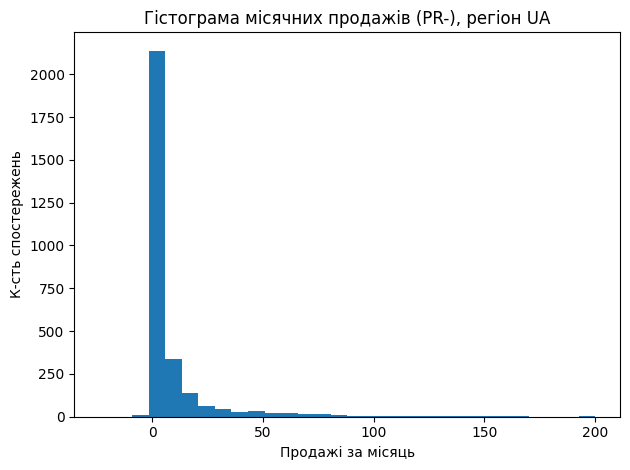

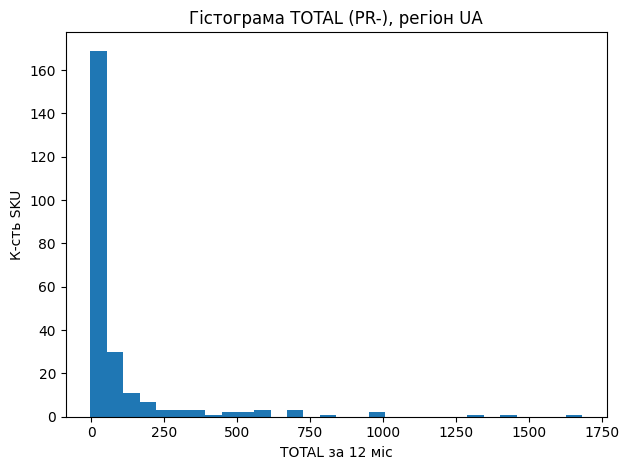

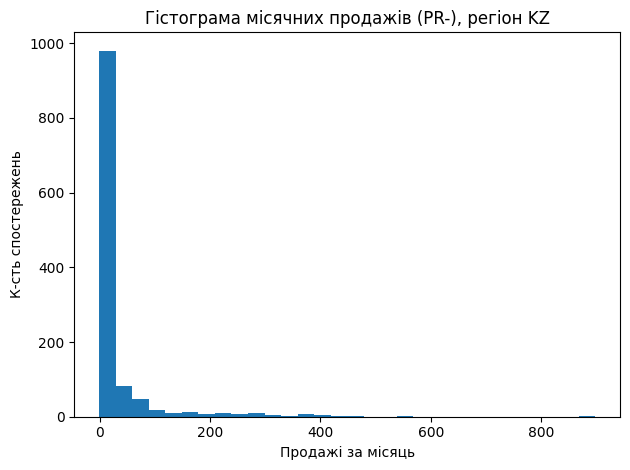

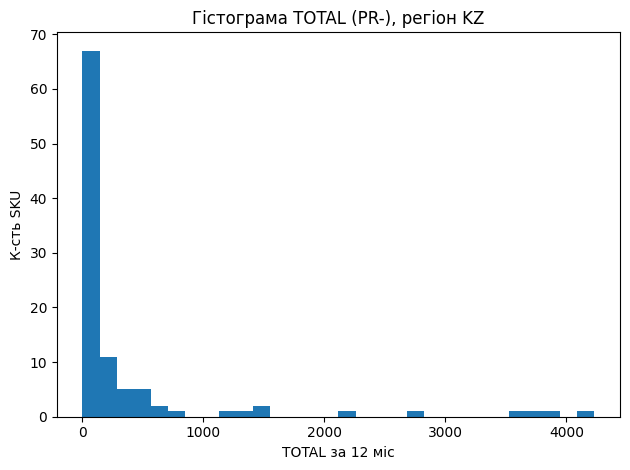

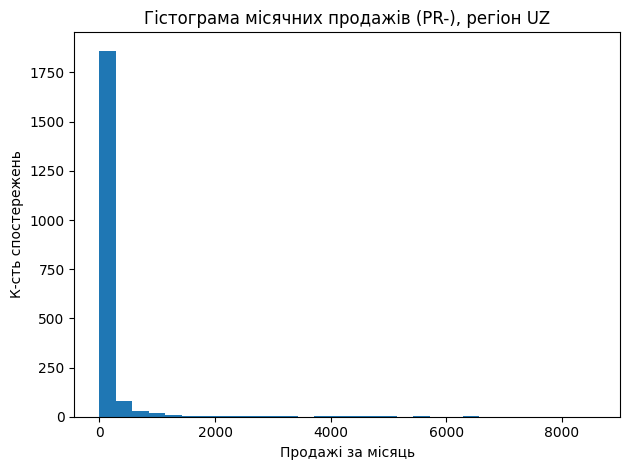

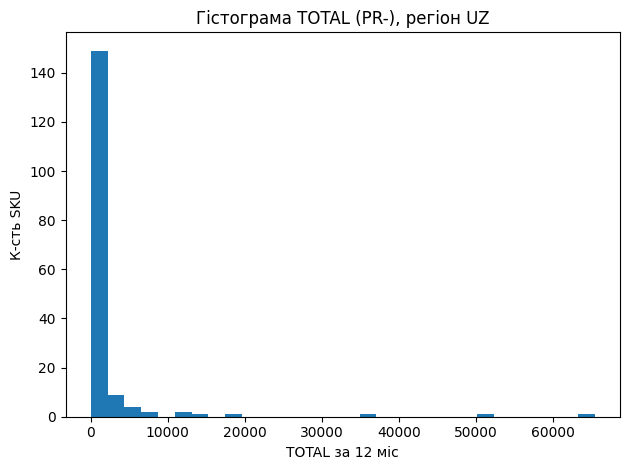

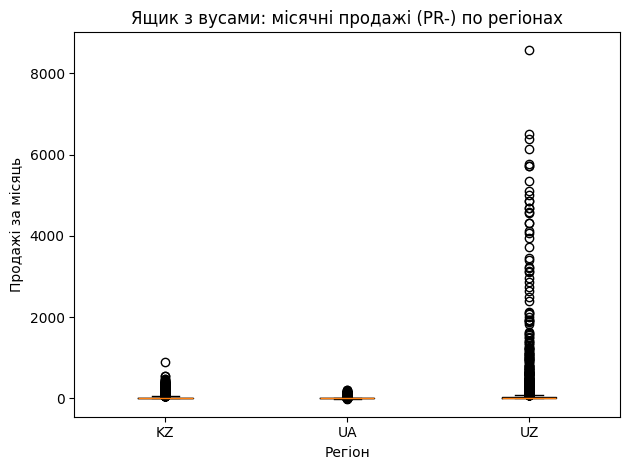

OK | STEP 7 завершено
- long:      DATA/EDA/normalized_long.csv
- summary:   DATA/EDA/normalized_summary_by_region.csv
- plots:     DATA/EDA/plots


<Figure size 640x480 with 0 Axes>

In [ ]:
%run DATA/step07_eda_normalized.py

## STEP 08. Аналіз одного SKU по регіонах

Мета: на прикладі одного SKU показати різницю продажів між регіонами UA/KZ/UZ.

Шукаємо PR-SKU, яке одночасно: kz ∈ low і при цьому в UA/UZ воно “контрастне”: або ua=high і uz=mid / або ua=mid і uz=high

Вибір серед кандидатів: беремо те SKU, у якого TOTAL в KZ (low-регіон) найбільший. Якщо таких SKU нема — система не падає, бере з YAML

max_pr_total_by_region = {'ua': 1682.0, 'kz': 4232.0, 'uz': 65452.0}

✅ Обрано показовий SKU: PR-DAE-49-3548-000-SET
Причина: Автовибір: kz_low, ua_high, uz_mid; KZ_TOTAL=210


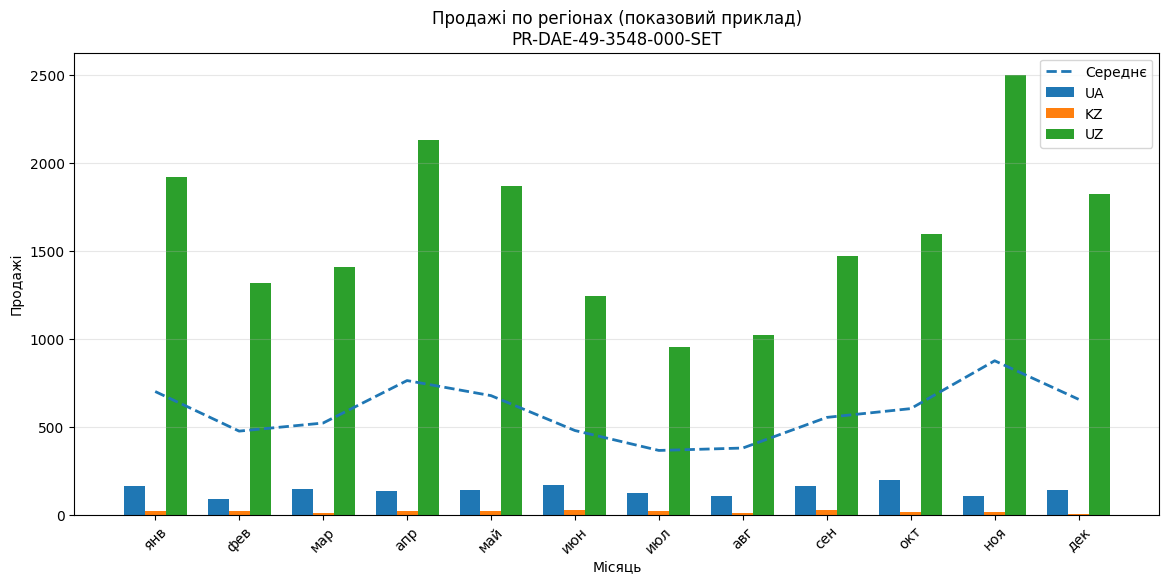

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

results_path = Path("DATA/SALES/RESULT/results.xlsx")
CFG_PATH = Path("config.yaml")

MONTHS = ["янв","фев","мар","апр","май","июн","июл","авг","сен","окт","ноя","дек"]

REGIONS = ["UA", "KZ", "UZ"]

def load_region_totals(region: str) -> pd.DataFrame:
    df = pd.read_excel(results_path, sheet_name=f"{region}-normalized", engine="openpyxl")

    key = "Symbol_normalized" if "Symbol_normalized" in df.columns else "Symbol"
    df = df.rename(columns={key: "SKU"}).copy()
    df["SKU"] = df["SKU"].astype(str).str.strip()

    # тільки PR-
    df = df[df["SKU"].str.startswith("PR-")].copy()

    # TOTAL
    if "TOTAL" in df.columns:
        df["TOTAL"] = pd.to_numeric(df["TOTAL"], errors="coerce").fillna(0.0)
    else:
        # якщо TOTAL нема — рахуємо з місяців
        for m in MONTHS:
            df[m] = pd.to_numeric(df.get(m, 0), errors="coerce").fillna(0.0)
        df["TOTAL"] = df[MONTHS].sum(axis=1)

    return df[["SKU", "TOTAL"]]

# --- 1) Збираємо TOTAL по регіонах ---
totals = {}
max_pr_total_by_region = {}

for r in REGIONS:
    t = load_region_totals(r)
    totals[r] = t
    max_pr_total_by_region[r.lower()] = float(t["TOTAL"].max()) if not t.empty else 0.0

print("max_pr_total_by_region =", max_pr_total_by_region)

# --- 2) 9 множин high/mid/low ---
sales = {k.lower(): {"high": set(), "mid": set(), "low": set()} for k in REGIONS}

def bucket(total: float, mx: float) -> str:
    if mx <= 0:
        return "low"
    share = total / mx
    if share >= 0.75:
        return "high"
    if share >= 0.25:
        return "mid"
    return "low"

# зробимо швидкий словник sku->total по кожному регіону
tot_map = {}
for r in REGIONS:
    tot_map[r.lower()] = dict(zip(totals[r]["SKU"], totals[r]["TOTAL"]))

# наповнюємо множини
for r in REGIONS:
    rl = r.lower()
    mx = max_pr_total_by_region[rl]
    for sku, total in tot_map[rl].items():
        sales[rl][bucket(float(total), mx)].add(sku)

# --- 3) кандидати: KZ low + ua high/mid  OR  ua low + uz high/mid, найбільше
def find_candidates():
    candidates = []

    # кандидати мають бути в KZ-low
    kz_low = sales["kz"]["low"]

    # варіант А: UA=high, UZ=mid
    a = kz_low & sales["ua"]["high"] & sales["uz"]["mid"]
    for sku in a:
        kz_total = float(tot_map["kz"].get(sku, 0.0))
        candidates.append((sku, "kz_low", "ua_high", "uz_mid", kz_total))

    # варіант Б: UA=mid, UZ=high
    b = kz_low & sales["ua"]["mid"] & sales["uz"]["high"]
    for sku in b:
        kz_total = float(tot_map["kz"].get(sku, 0.0))
        candidates.append((sku, "kz_low", "ua_mid", "uz_high", kz_total))

    return candidates


cands = find_candidates()

# --- 4) Вибір “найкращого”: той, у кого low TOTAL найбільший (найпоказовіший серед low)
if cands:
    # сортуємо за kz_total (найбільший — найпоказовіший у low)
    cands.sort(key=lambda x: x[4], reverse=True)
    best_sku, kz_tag, ua_tag, uz_tag, kz_total = cands[0]
    reason = f"Автовибір: {kz_tag}, {ua_tag}, {uz_tag}; KZ_TOTAL={kz_total:.0f}"
else:
    # fallback на YAML
    best_sku = None
    if CFG_PATH.exists():
        with open(CFG_PATH, "r", encoding="utf-8") as f:
            cfg = yaml.safe_load(f) or {}
        best_sku = ((cfg.get("analysis") or {}).get("sku_example")) or None

    if not best_sku:
        best_sku = "PR-DAE-47-3538-000-SET"

    reason = "Fallback: не знайдено SKU з KZ=low та (UA/UZ=high+mid) → беремо analysis.sku_example"

print("\n✅ Обрано показовий SKU:", best_sku)
print("Причина:", reason)

# --- 5) Тепер малюємо “гарний” графік по 3 регіонах для best_sku ---
def load_months(region: str, sku: str) -> np.ndarray:
    df = pd.read_excel(results_path, sheet_name=f"{region}-normalized", engine="openpyxl")
    key = "Symbol_normalized" if "Symbol_normalized" in df.columns else "Symbol"
    df = df.rename(columns={key: "SKU"}).copy()
    df["SKU"] = df["SKU"].astype(str).str.strip()
    row = df[df["SKU"] == sku]
    if row.empty:
        return np.zeros(12, dtype=float)
    row = row.iloc[0]
    vals = []
    for m in MONTHS:
        vals.append(float(pd.to_numeric(row.get(m, 0), errors="coerce") or 0))
    return np.array(vals, dtype=float)

ua_y = load_months("UA", best_sku)
kz_y = load_months("KZ", best_sku)
uz_y = load_months("UZ", best_sku)
mean_y = np.mean([ua_y, kz_y, uz_y], axis=0)

x = np.arange(len(MONTHS))
w = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - w, ua_y, width=w, label="UA")
plt.bar(x,     kz_y, width=w, label="KZ")
plt.bar(x + w, uz_y, width=w, label="UZ")

plt.plot(x, mean_y, linestyle="--", linewidth=2, label="Середнє")

plt.xticks(x, MONTHS, rotation=45)
plt.ylabel("Продажі")
plt.xlabel("Місяць")
plt.title(f"Продажі по регіонах (показовий приклад)\n{best_sku}")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

# %run DATA/step08_sku_region_analysis.py


# Висновок (аналіз одного SKU PR-DAE-49-3548-000-SET по регіонах)
### UZ (Узбекистан)

Продажі стабільно та суттєво вищі за інші регіони протягом усього року. Спостерігається чітка сезонність із піками у квітні, листопаді та грудні. Саме регіон UZ визначає основний вклад у середнє значення продажів (пунктирна лінія).

### UA (Україна)

Продажі знаходяться на середньому рівні, значно нижчі за UZ, але істотно вищі за KZ. Динаміка відносно рівна, з помірним зростанням у жовтні–листопаді, що може вказувати на сезонний попит.

### KZ (Казахстан)

Продажі мінімальні впродовж усього періоду, практично на порядки нижчі за UZ. SKU знаходиться в зоні low-demand, що робить його кандидатом на перегляд асортименту або зміну логістичної/маркетингової стратегії в цьому регіоні.

### Порівняльний висновок

Один і той самий SKU демонструє три різні профілі продажів у різних регіонах:

*   UZ → high
*   UA → mid
*   KZ → low

Це підтверджує гіпотезу, що регіон є ключовим фактором впливу на попит, і використання агрегованих показників без розділення за регіонами може призводити до хибних управлінських рішень.


## STEP 09. KMeans кластеризація SKU

Мета: сегментувати PR-товари за профілем продажів.

Робимо:
- збираємо єдиний датасет по SKU, сумуючи UA+KZ+UZ
- стандартизуємо ознаки
- підбираємо k за:
  - методом “ліктя” (inertia)
  - метрикою silhouette
- навчаємо KMeans та додаємо `cluster_id`

Результат:
- `DATA/ML/clusters_pr.csv`
- `DATA/ML/plots/elbow.png`, `DATA/ML/plots/silhouette.png`
- лист `PR_CLUSTERS` у `results.xlsx`


STEP 09 | KMeans кластеризація SKU (PR-)
Обрано k=2 (максимум silhouette).


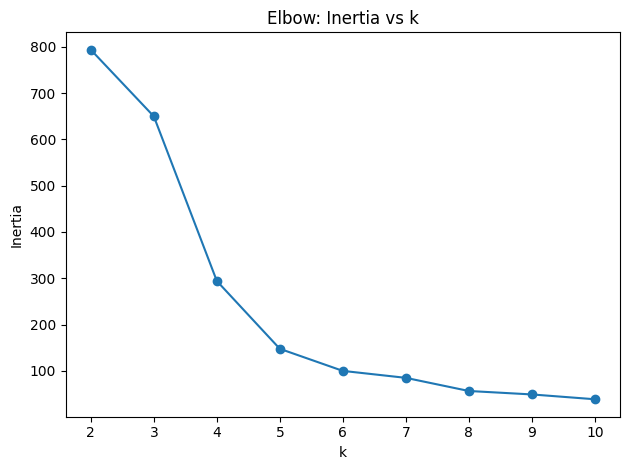

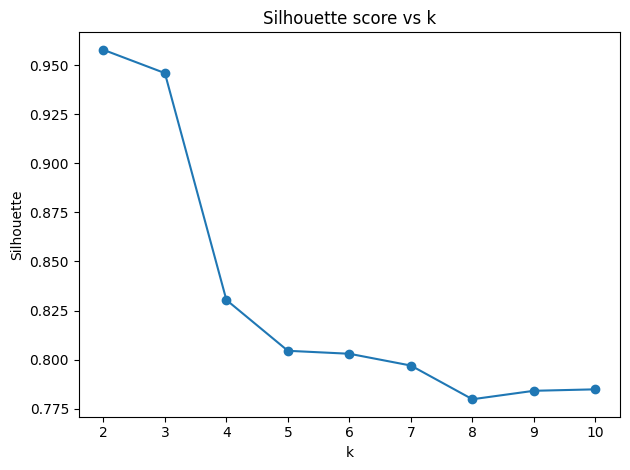

OK | STEP 09 завершено
- CSV:   DATA/ML/clusters_pr.csv
- sheet: PR_CLUSTERS у DATA/SALES/RESULT/results.xlsx
- plots: DATA/ML/plots


<Figure size 640x480 with 0 Axes>

In [ ]:
%run DATA/step09_kmeans_clustering.py


### Висновок (кластеризація SKU методом K-means)

Для сегментації PR-товарів за профілем продажів було застосовано алгоритм **K-means**.

Оптимальну кількість кластерів визначено за допомогою двох підходів:
- **метод “ліктя” (Elbow method)** — аналіз зміни інерції при збільшенні кількості кластерів;
- **метрика Silhouette score** — оцінка якості розділення об’єктів між кластерами.

На графіку Elbow спостерігається різке зменшення інерції до **k = 2**,
після чого швидкість покращення суттєво знижується.
Водночас максимальне значення Silhouette score також досягається при **k = 2**.

На основі цього було обрано **k = 2** як оптимальну кількість кластерів.
Отримані кластери дозволяють розділити SKU на дві групи з різними
характеристиками продажів, що є корисним для подальшого аналізу попиту
та прийняття управлінських рішень.


## STEP 10. ML: прогноз TOTAL (RandomForest)

Мета: показати приклад supervised ML на даних продажів.

Оскільки є лише 12 місяців історії, робимо показовий ML-кейс:
модель навчається на профілі продажів (12 місяців + Stock/Month_sales) і прогнозує `TOTAL`.

Результат:
- метрики MAE та R² (baseline vs модель)
- графіки:
  - `DATA/ML/plots/pred_vs_true.png`
  - `DATA/ML/plots/feature_importance.png`
- артефакт моделі: `DATA/ML/model_rf_total.joblib`


STEP 10 | ML: RandomForestRegressor (прогноз TOTAL)
ML (RandomForestRegressor) — прогноз TOTAL за профілем продажів (PR-)
- Baseline (mean): MAE=3469.28, R2=-0.032
- Model (RF):      MAE=727.24, R2=0.866


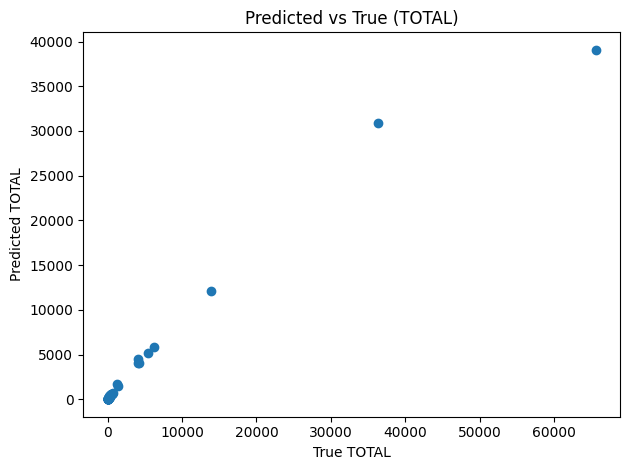

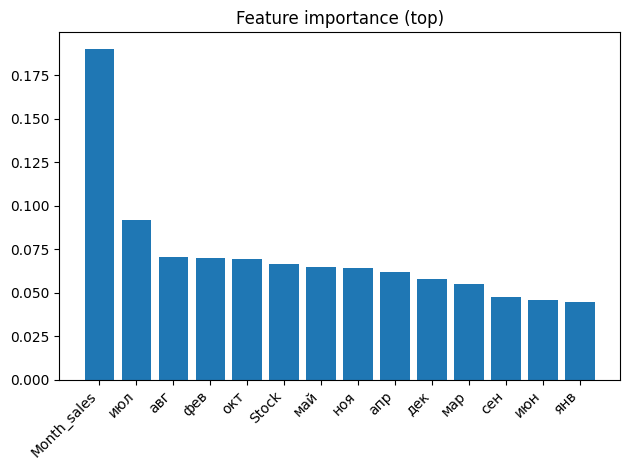

OK | STEP 10 завершено
- model: DATA/ML/model_rf_total.joblib
- plots: DATA/ML/plots


<Figure size 640x480 with 0 Axes>

In [ ]:
%run DATA/step10_ml_regression_total.py


### Інтерпретація результатів прогнозування

На графіку **Predicted vs True (TOTAL)** зображено співвідношення між
фактичними та прогнозованими значеннями сумарних продажів.

Більшість точок розташовані поблизу діагоналі, що свідчить про
високу точність прогнозу моделі RandomForest.
Особливо добре модель відтворює середні та великі значення TOTAL,
що є критично важливим з точки зору бізнес-планування.

Невеликі відхилення для окремих SKU пояснюються:
- нерівномірністю продажів,
- наявністю викидів,
- обмеженим обсягом історичних даних.


### Аналіз важливості ознак (Feature Importance)

Графік важливості ознак показує, які фактори найбільше впливають
на прогноз сумарних продажів (TOTAL) у моделі RandomForest.

Найважливішою ознакою є **Month_sales**, що логічно, оскільки
вона відображає типовий середньомісячний рівень продажів товару.
Також суттєвий вплив мають окремі місяці та показник **Stock**,
який характеризує наявність товару.

Це підтверджує, що модель виявляє інтуїтивно зрозумілі та
бізнес-логічні залежності, а не випадкові кореляції.


Результати EDA та кластеризації показали, що товари мають різні
профілі продажів і сезонність. Побудована ML-модель враховує ці
характеристики та дозволяє ефективно прогнозувати сумарні продажі,
що підтверджується високим значенням R² та низькою помилкою MAE.


# Висновок
В результаті дипломної рооти побудувано пайплайн аналізу продажів: від нормалізації даних і EDA, через кластеризацію SKU, до прогнозування сумарних продажів за допомогою ML. RandomForest показав значно кращі результати порівняно з базовою моделлю, що підтверджує наявність складних нелінійних залежностей у даних.